In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plotting(t, x, v, E, title=""):
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    axs[0, 0].plot(t, x, label="x(t)", color="skyblue")
    axs[0, 0].set_xlabel("t [s]")
    axs[0, 0].set_ylabel("x [m]")
    axs[0, 0].set_title("Położenie w czasie")
    axs[0, 0].grid()

    axs[0, 1].plot(t, v, label="v(t)", color="lime")
    axs[0, 1].set_xlabel("t [s]")
    axs[0, 1].set_ylabel("v [m/s]")
    axs[0, 1].set_title("Prędkość w czasie")
    axs[0, 1].grid()

    axs[1, 0].plot(x, v, label="Portret fazowy", color="fuchsia")
    axs[1, 0].set_xlabel("x [m]")
    axs[1, 0].set_ylabel("v [m/s]")
    axs[1, 0].set_title("Portret fazowy")
    axs[1, 0].grid()

    axs[1, 1].plot(t, E, label="Energia", color="red")
    axs[1, 1].set_xlabel("t [s]")
    axs[1, 1].set_ylabel("E [J]")
    axs[1, 1].set_title("Energia w czasie")
    axs[1, 1].grid()

    plt.tight_layout()
    plt.show()

l1 = 1 
l2 = 1/np.sqrt(8)
m = 1
# Potencjał
def phi(x):
    return -np.exp(-x**2/l1**2)-8*np.exp(-(x-2)**2/l2**2)

def acceleration(x, v=0, alpha=0):
    delta_x = 0.001
    return -1/m*(phi(x + delta_x) - phi(x - delta_x)) / (2 * delta_x) - v * alpha

def energy(x, v):
    return 0.5 * m * v**2 + phi(x)

# Metody - każda ma wprowadzony opór domyślnie 0, z możliwością ustawienia.
def euler(x ,v ,dt, alpha=0):
    a = acceleration(x, v, alpha)
    x_next = x + dt * v
    v_next = v + dt * a
    return x_next, v_next

def verlett(x ,v ,dt, alpha=0):
    a = acceleration(x)
    x_next = x + dt * v + 0.5*a*dt**2
    a_next = acceleration(x_next)
    v_next = v + dt/2 * (a+a_next)
    E = energy(x, v)
    return x_next, v_next

def rk4_step(x, v, dt, alpha=0):
    k1x = v
    k1v = acceleration(x, k1x, alpha)

    k2x = v + dt/2 * k1v
    k2v = acceleration(x + dt/2 * k1x, k2x, alpha)

    k3x = v + dt/2 * k2v
    k3v = acceleration(x + dt/2 * k2x, k3x, alpha)

    k4x = v + dt * k3v
    k4v = acceleration(x + dt * k3x, k4x, alpha)

    x_next = x + dt/6 * (k1x + 2 * k2x + 2 * k3x + k4x)
    v_next = v + dt/6 * (k1v + 2 * k2v + 2 * k3v + k4v)

    return x_next, v_next

Zadanie 1. Euler

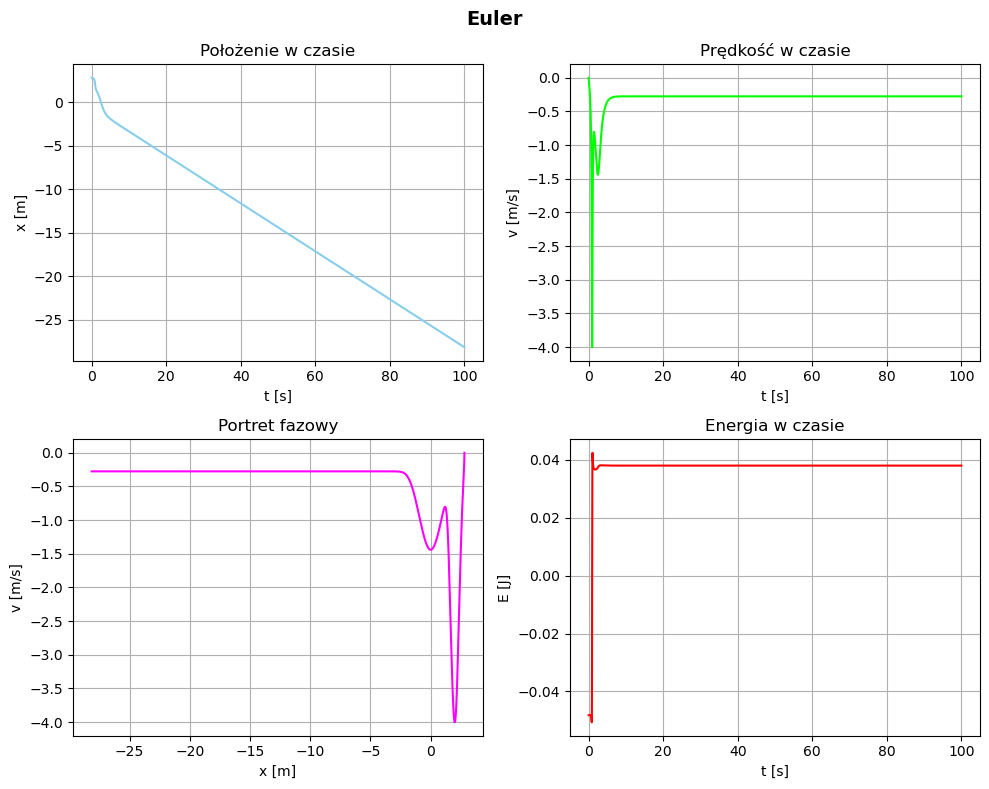

In [3]:
delta_t = 0.001
t = 0
t_max = 100
x_euler = [2.8]
v_euler = [0]
t_euler = [t]
while t < t_max:
    x_next, v_next = euler(x_euler[-1], v_euler[-1], delta_t)
    x_euler.append(x_next)
    v_euler.append(v_next)
    t_euler.append(t)
    t += delta_t

v_euler = np.array(v_euler)
x_euler = np.array(x_euler)
E_euler = energy(x_euler, v_euler)

plotting(t_euler,x_euler,v_euler,E_euler, "Euler")

Zadanie 1. Verlet

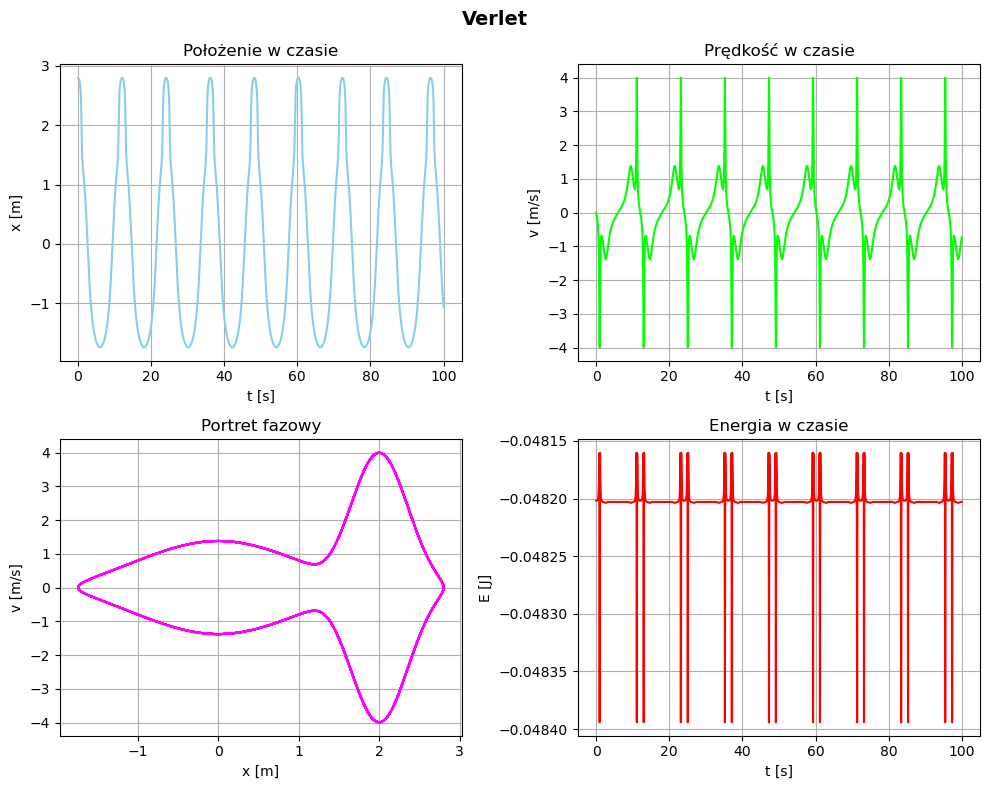

In [4]:
delta_t = 0.001
t = 0
t_max = 100
x_verlett = [2.8]
v_verlett = [0]
t_verlett = [t]
while t < t_max:
    x_next, v_next = verlett(x_verlett[-1], v_verlett[-1], delta_t)
    x_verlett.append(x_next)
    v_verlett.append(v_next)
    t_verlett.append(t)
    t += delta_t

v_verlett = np.array(v_verlett)
x_verlett = np.array(x_verlett)
E_verlett = energy(x_verlett, v_verlett)

plotting(t_verlett,x_verlett,v_verlett,E_verlett, "Verlet")


Zadanie 1. RK4

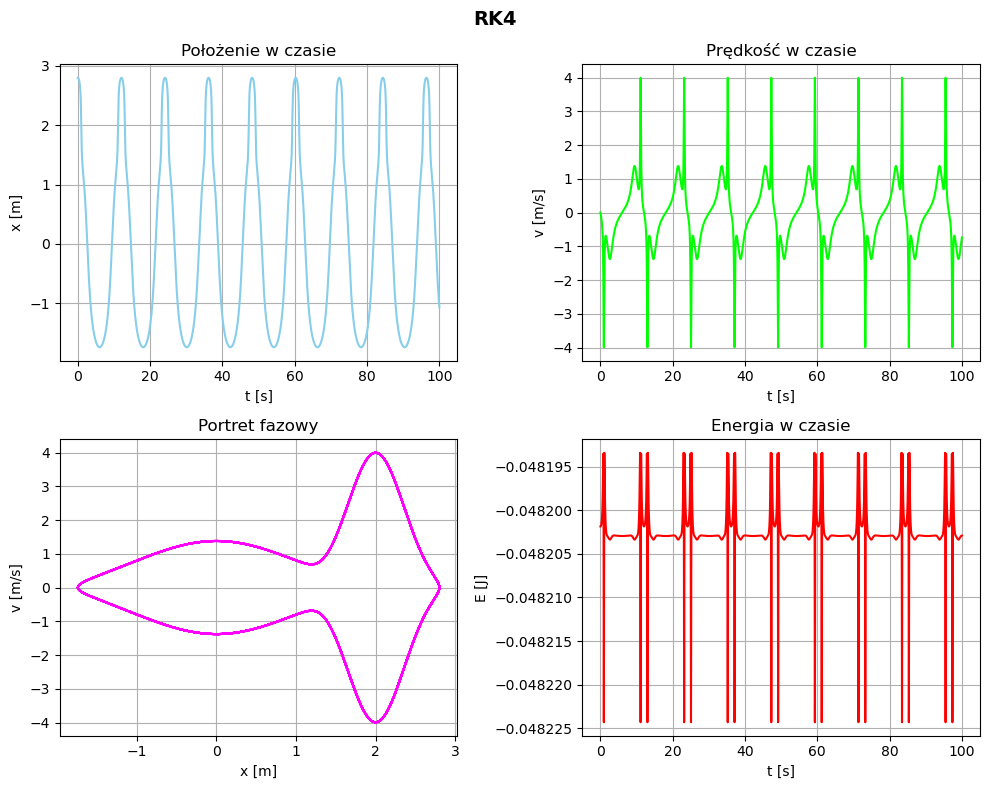

In [6]:
delta_t = 0.001
t = 0
t_max = 100
x_RK4 = [2.8]
v_RK4 = [0]
t_RK4 = [t]
while t < t_max:
    x_next, v_next = rk4_step(x_RK4[-1], v_RK4[-1], delta_t, 0)
    x_RK4.append(x_next)
    v_RK4.append(v_next)
    t_RK4.append(t)
    t += delta_t

v_RK4 = np.array(v_RK4)
x_RK4 = np.array(x_RK4)
E_RK4 = energy(x_RK4, v_RK4)

plotting(t_RK4,x_RK4,v_RK4,E_RK4, "RK4")

Różne kroki czasowe:

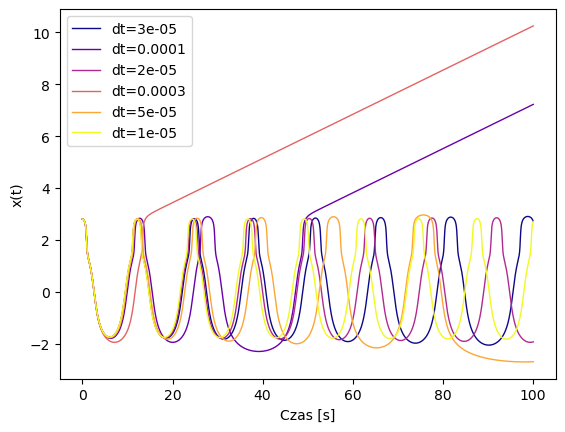

dt=3e-05: x(10s) ≈ 0.5513514675171631
dt=0.0001: x(10s) ≈ 0.06749505117997236
dt=2e-05: x(10s) ≈ 0.6059969527274213
dt=0.0003: x(10s) ≈ -1.4998729525221688
dt=5e-05: x(10s) ≈ 0.431524164040688
dt=1e-05: x(10s) ≈ 0.6573130945631517


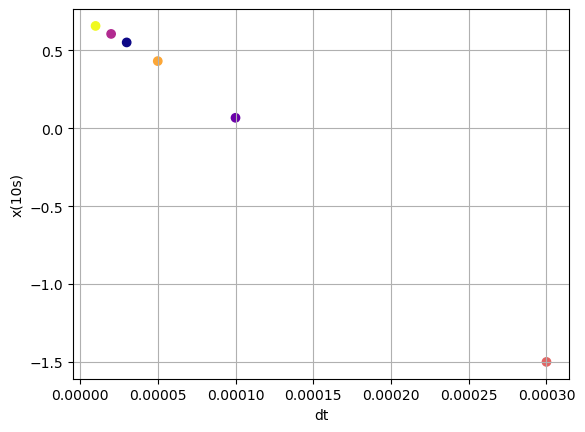

In [9]:
#dts = [0.05,0.04,0.03,0.02,0.01, 0.005, 0.001, 0.002, 0.003, 0.004, 0.0005, 0.0001, 0.00005, 0.00001]
dts = [0.00003, 0.0001, 0.00002, 0.0003, 0.00005, 0.00001]
colors = plt.cm.plasma(np.linspace(0, 1, len(dts)))
t_target = 10  # Szukamy t ≈ 10s
tolerance = 0.001

x_values_at_t_target = []

for dt, color in zip(dts, colors):
    t = 0
    t_max = 100
    x_euler = [2.8]
    v_euler = [0]
    t_euler = [t]
    
    while t < t_max:
        x_next, v_next = euler(x_euler[-1], v_euler[-1], dt)
        x_euler.append(x_next)
        v_euler.append(v_next)
        t_euler.append(t)
        t += dt

    v_euler = np.array(v_euler)
    x_euler = np.array(x_euler)

    idx = np.argmin(np.abs(np.array(t_euler) - t_target))
    closest_t = t_euler[idx]
    x_values_at_t_target.append(x_euler[idx])

    plt.plot(t_euler, x_euler, label=f"dt={dt}", color=color, linewidth=1)

plt.legend(loc="upper left")
plt.xlabel("Czas [s]")
plt.ylabel("x(t)")
plt.show()

for dt, x_val in zip(dts, x_values_at_t_target):
    print(f"dt={dt}: x(10s) ≈ {x_val}")
    
plt.scatter(dts, x_values_at_t_target, c=colors)
plt.xlabel("dt")
plt.ylabel("x(10s)")
plt.grid()


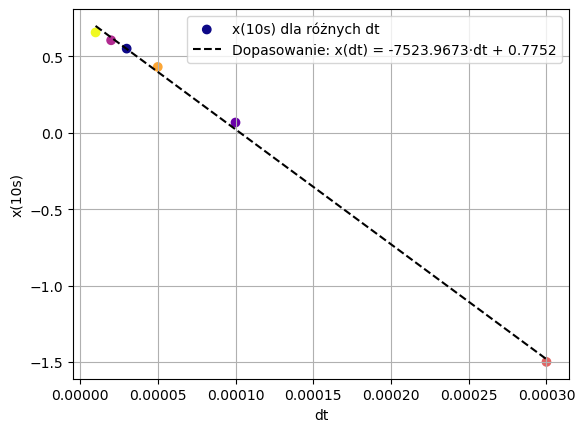

Prosta dopasowana: x(dt) ≈ -7523.96729 * dt + 0.77517
Przybliżona wartość x(10s) dla dt→0: 0.77517


In [10]:
# Dopasowanie prostej do wykresu dla Eulera
sorted_data = sorted(zip(dts, x_values_at_t_target))
dts_sorted, x_vals_sorted = zip(*sorted_data)

cutoff_index = -6
small_dts = np.array(dts_sorted[cutoff_index:])
small_x = np.array(x_vals_sorted[cutoff_index:])

# Dopasowanie prostej: x = a * dt + b
coeffs = np.polyfit(small_dts, small_x, 1)
a, b = coeffs

dt_fit = np.linspace(min(small_dts), max(small_dts), 100)
x_fit = a * dt_fit + b


plt.scatter(dts, x_values_at_t_target, label="x(10s) dla różnych dt", c=colors)
plt.plot(dt_fit, x_fit, 'k--', label=f'Dopasowanie: x(dt) = {a:.4f}·dt + {b:.4f}')
plt.xlabel("dt")
plt.ylabel("x(10s)")
plt.grid(True)
plt.legend()
plt.show()

print(f"Prosta dopasowana: x(dt) ≈ {a:.5f} * dt + {b:.5f}")
print(f"Przybliżona wartość x(10s) dla dt→0: {b:.5f}")


Zadanie 2.

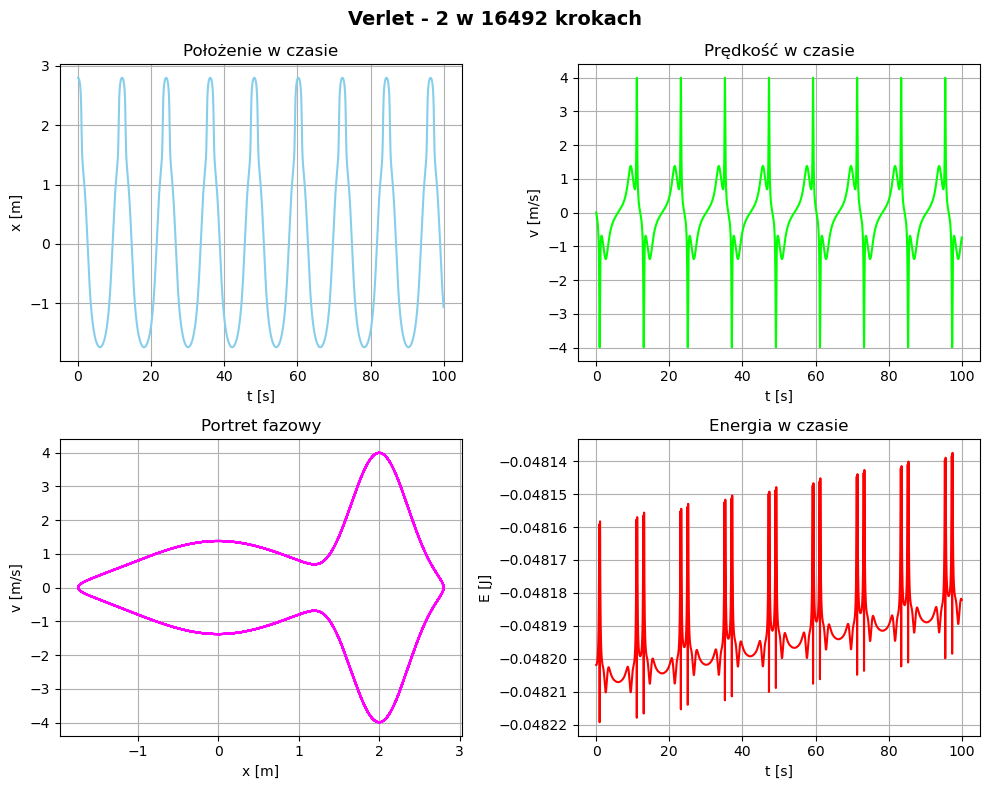

In [11]:
x = [2.8]
v = [0]

# tolerancja
tol = 1e-7
# rzad metody
d = 2
# liczba krokow do wykonania
steps = 0

t = 0
time = [t]
delta_t = 0.001
delta_t_tab =[delta_t]
t_max = 100

while t < t_max:
    
    x_big, v_big = verlett(x[-1], v[-1], 2*delta_t)

    x_small, v_small = verlett(x[-1], v[-1], delta_t)
    x_big_p, v_big_p = verlett(x_small, v_small, delta_t)

    epsilon_x = np.abs((x_big_p-x_big)/(2**d-1))
    epsilon_v = np.abs((v_big_p-v_big)/(2**d-1))
    epsilon = max(epsilon_x, epsilon_v)

    if (epsilon <= tol):
        
        x.append(x_big_p)
        v.append(v_big_p)
        time.append(t)
        delta_t_tab.append(delta_t)
        t += 2*delta_t
        steps += 1
            
    delta_t = 0.9 * delta_t * (tol/epsilon)**(1/(d+1))
    
    

v = np.array(v)
x = np.array(x)
E = 0.5*v**2 + phi(x)

plotting(time,x,v,E, f"Verlet - 2 w {steps} krokach")

In [35]:
# Funkcja uniwersalna z mozliwoscia wyboru jednej z wczesniejszych metod
def adaptive_solver(step_func, d, name, x0=2.8, v0=0, delta_t0=0.001, t_max=100, tol=1e-7, alpha=0):
    x = [x0]
    v = [v0]
    t = 0
    steps = 0
    time = [t]
    delta_t = delta_t0
    delta_t_tab = [delta_t]

    while t < t_max:
        x_big, v_big = step_func(x[-1], v[-1], 2*delta_t, alpha)
        x_small, v_small = step_func(x[-1], v[-1], delta_t, alpha)
        x_big_p, v_big_p = step_func(x_small, v_small, delta_t, alpha)

        epsilon_x = np.abs((x_big_p - x_big) / (2**d - 1))
        epsilon_v = np.abs((v_big_p - v_big) / (2**d - 1))
        epsilon = max(epsilon_x, epsilon_v)

        if epsilon <= tol:
            x.append(x_big_p)
            v.append(v_big_p)
            t += 2*delta_t
            time.append(t)
            delta_t_tab.append(delta_t)
            steps += 1

        delta_t = 0.9 * delta_t * (tol/epsilon)**(1/(d+1))

    x = np.array(x)
    v = np.array(v)
    E = 0.5*v**2 + phi(x)
    
    return time, delta_t_tab, x, v, steps


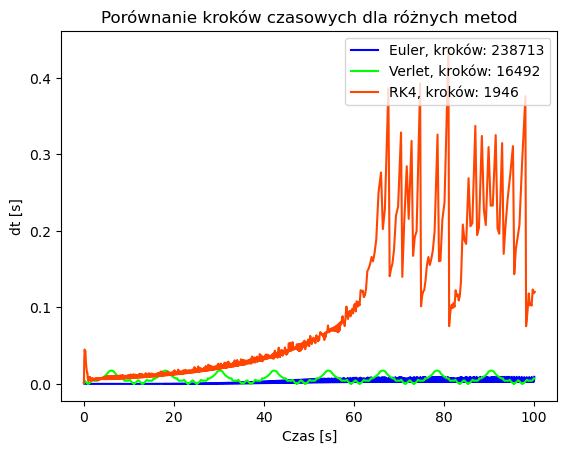

In [37]:
# Porównanie kroków czasowych dla różnych metod
time_rk4, dt_rk4, x_rk4, v_rk4, steps_rk4 = adaptive_solver(rk4_step, d=3, name="RK4", alpha=0.5)
time_euler, dt_euler, x_euler, v_euler, steps_euler = adaptive_solver(euler, d=1, name="Euler", alpha=0.5)
time_verlett, dt_verlett, x_verlett, v_verlett, steps_verlett = adaptive_solver(verlett, d=2, name="Verlet", alpha=0.5)

plt.figure("Coś tam")
plt.plot(time_euler, dt_euler, label=f"Euler, kroków: {steps_euler}", color="blue")
plt.plot(time_verlett, dt_verlett, label=f"Verlet, kroków: {steps_verlett}", color="lime")
plt.plot(time_rk4, dt_rk4, label=f"RK4, kroków: {steps_rk4}", color="orangered")

plt.legend(loc="upper right")
plt.xlabel("Czas [s]")
plt.ylabel("dt [s]")
plt.title("Porównanie kroków czasowych dla różnych metod")
plt.show()

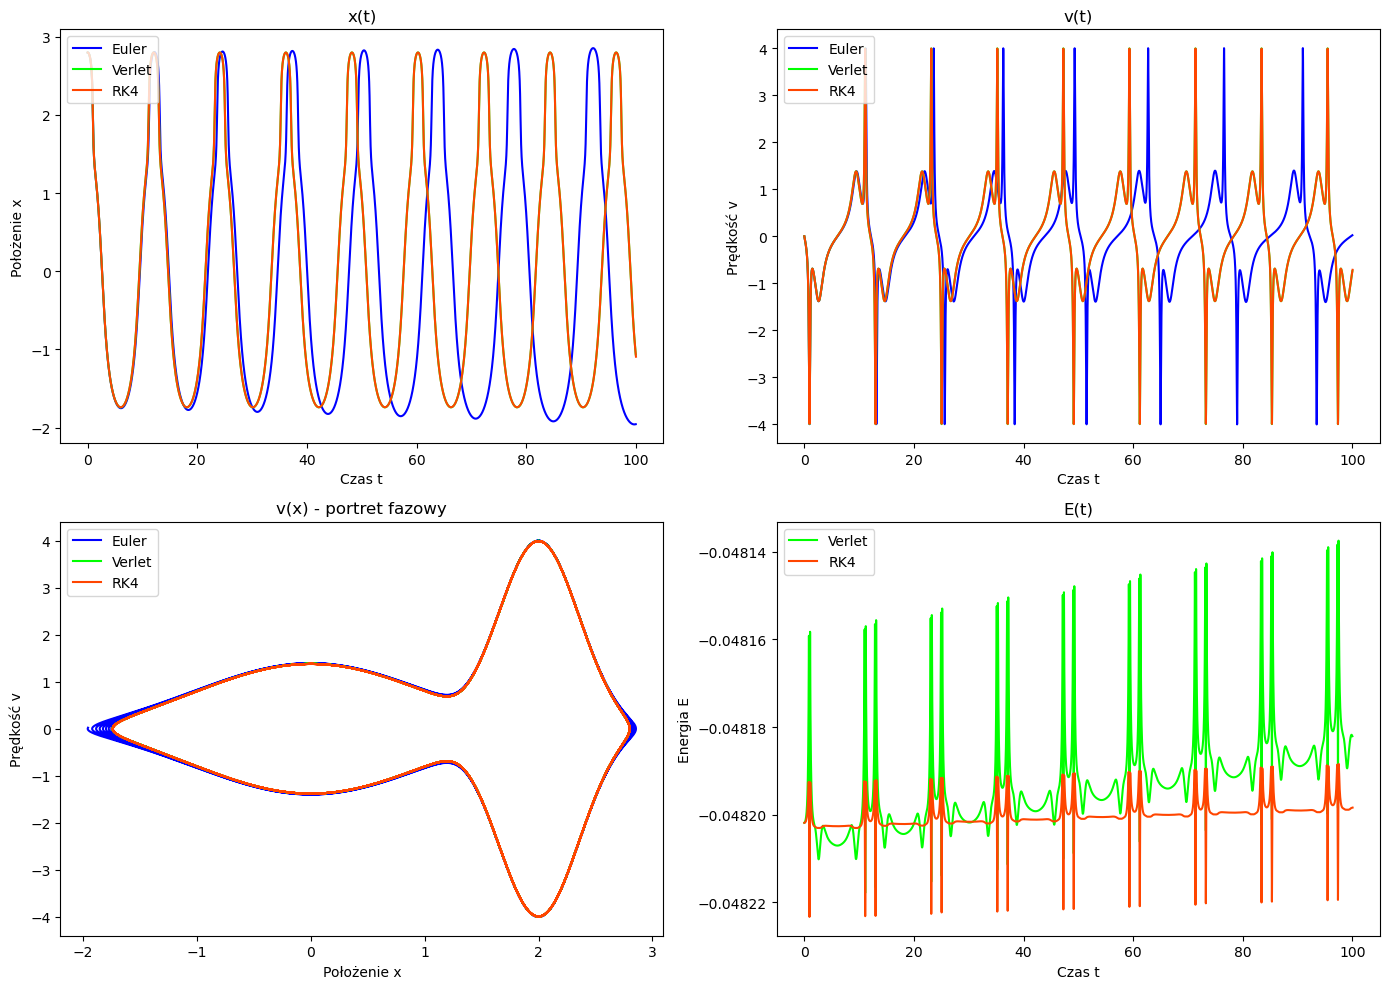

In [20]:
# Porównanie wykresów dla różnych metod
E_rk4 = energy(x_rk4, v_rk4)
E_euler = energy(x_euler, v_euler)
E_verlett = energy(x_verlett, v_verlett)

plt.figure(figsize=(14, 10))

# 1. x(t)
plt.subplot(2, 2, 1)
plt.plot(time_euler, x_euler, label="Euler", color="blue")
plt.plot(time_verlett, x_verlett, label="Verlet", color="lime")
plt.plot(time_rk4, x_rk4, label="RK4", color="orangered")
plt.title("x(t)")
plt.xlabel("Czas t")
plt.ylabel("Położenie x")
plt.legend(loc="upper left")

# 2. v(t)
plt.subplot(2, 2, 2)
plt.plot(time_euler, v_euler, label="Euler", color="blue")
plt.plot(time_verlett, v_verlett, label="Verlet", color="lime")
plt.plot(time_rk4, v_rk4, label="RK4", color="orangered")
plt.title("v(t)")
plt.xlabel("Czas t")
plt.ylabel("Prędkość v")
plt.legend(loc="upper left")

# 3. v(x)
plt.subplot(2, 2, 3)
plt.plot(x_euler, v_euler, label="Euler", color="blue")
plt.plot(x_verlett, v_verlett, label="Verlet", color="lime")
plt.plot(x_rk4, v_rk4, label="RK4", color="orangered")
plt.title("v(x) - portret fazowy")
plt.xlabel("Położenie x")
plt.ylabel("Prędkość v")
plt.legend(loc="upper left")

# 4. E(t)
plt.subplot(2, 2, 4)
#plt.plot(time_euler, E_euler, label="Euler", color="blue") #zakomentowane by było widać różnice na E(t) 
plt.plot(time_verlett, E_verlett, label="Verlet", color="lime")
plt.plot(time_rk4, E_rk4, label="RK4", color="orangered")
plt.title("E(t)")
plt.xlabel("Czas t")
plt.ylabel("Energia E")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

Zad.4 Metoda Trapezów

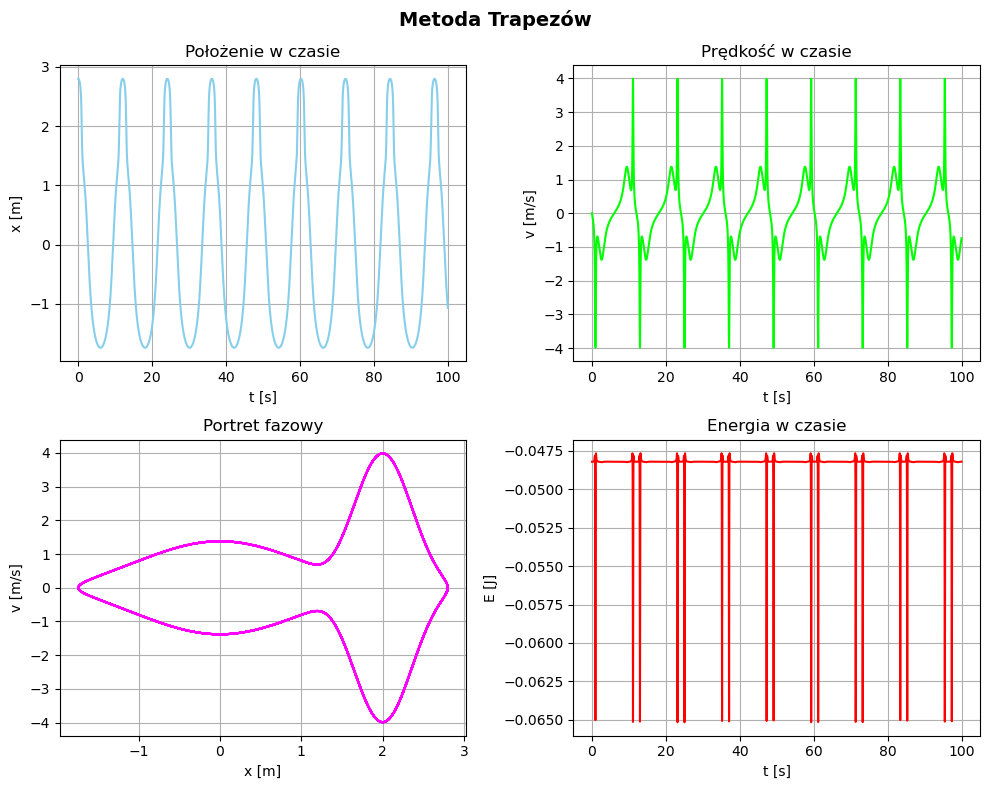

In [12]:
delta_t = 0.01
delta_x = 0.001
tol = 1e-7
t = 0
t_max = 100
x_trapez = [2.8]
v_trapez = [0]
t_trapez = [t]

def d2phi(x):
    return (phi(x+delta_x) - 2*phi(x) + phi(x-delta_x))/(delta_x**2)

def trapez(x ,v ,dt, alpha=0):
    x_next = x
    v_next = v
    dx = dv = float('inf')
    
    while (abs(dx) > tol and abs(dv) > tol):
        
        F1 = x_next - x - dt/2*(v_next + v)
        F2 = v_next - v - dt/2*(acceleration(x_next, v_next, alpha) + acceleration(x, v, alpha))

        a_matrix = 1
        b_matrix = -dt/2
        c_matrix = dt/2/m * d2phi(x_next)
        d_matrix = 1 + dt/2 * alpha

        # Układ równań: M * [Δx, Δv] = -[F1, F2]
        M = np.array([[a_matrix, b_matrix], [c_matrix, d_matrix]])
        F = np.array([-F1, -F2])

        delta = np.linalg.solve(M, F)
        dx, dv = delta

        x_next += dx
        v_next += dv

    return x_next, v_next
    
while t < t_max:
    x, v = trapez(x_trapez[-1], v_trapez[-1], delta_t)
    x_trapez.append(x)
    v_trapez.append(v)
    t_trapez.append(t)
    t += delta_t
    
v_trapez = np.array(v_trapez)
x_trapez = np.array(x_trapez)
E_trapez = energy(x_trapez, v_trapez)

plotting(t_trapez,x_trapez,v_trapez,E_trapez, "Metoda Trapezów")

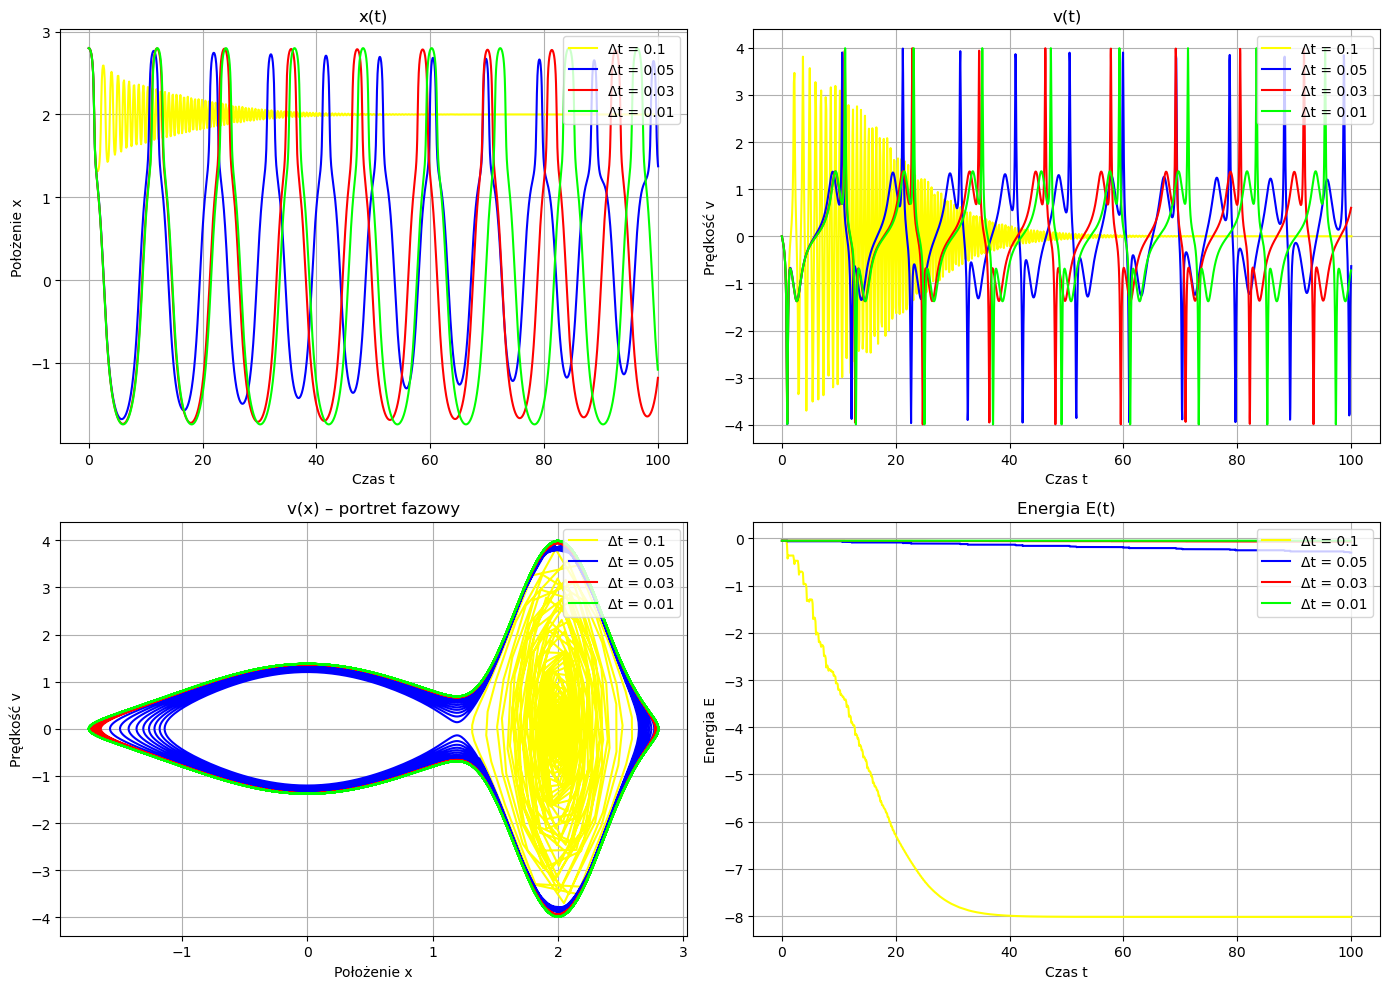

In [58]:
# Różne delta_t
colors = {
    0.1: 'yellow',
    0.05: 'blue',
    0.03: 'red',
    0.01: 'lime'
}

def run_simulation(delta_t, t_max=100, x0=2.8, v0=0):
    t = 0
    x_euler = [x0]
    v_euler = [v0]
    t_euler = [t]

    while t < t_max:
        x_next, v_next = rk4_step(x_euler[-1], v_euler[-1], delta_t)
        x_euler.append(x_next)
        v_euler.append(v_next)
        t += delta_t
        t_euler.append(t)

    x_euler = np.array(x_euler)
    v_euler = np.array(v_euler)
    E_euler = energy(x_euler, v_euler)
    t_euler = np.array(t_euler)

    return t_euler, x_euler, v_euler, E_euler

delta_ts = [0.1, 0.05, 0.03, 0.01]
results = {}

for dt in delta_ts:
    t, x, v, E = run_simulation(dt)
    results[dt] = (t, x, v, E)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# x(t)
for dt in delta_ts:
    t, x, _, _ = results[dt]
    axs[0, 0].plot(t, x, label=f"Δt = {dt}", color=colors[dt])
axs[0, 0].set_title("x(t)")
axs[0, 0].set_xlabel("Czas t")
axs[0, 0].set_ylabel("Położenie x")
axs[0, 0].legend(loc="upper right")
axs[0, 0].grid(True)

# v(t)
for dt in delta_ts:
    t, _, v, _ = results[dt]
    axs[0, 1].plot(t, v, label=f"Δt = {dt}", color=colors[dt])
axs[0, 1].set_title("v(t)")
axs[0, 1].set_xlabel("Czas t")
axs[0, 1].set_ylabel("Prędkość v")
axs[0, 1].legend(loc="upper right")
axs[0, 1].grid(True)

# v(x)
for dt in delta_ts:
    _, x, v, _ = results[dt]
    axs[1, 0].plot(x, v, label=f"Δt = {dt}", color=colors[dt])
axs[1, 0].set_title("v(x) – portret fazowy")
axs[1, 0].set_xlabel("Położenie x")
axs[1, 0].set_ylabel("Prędkość v")
axs[1, 0].legend(loc="upper right")
axs[1, 0].grid(True)

# E(t)
for dt in delta_ts:
    t, _, _, E = results[dt]
    axs[1, 1].plot(t, E, label=f"Δt = {dt}", color=colors[dt])
axs[1, 1].set_title("Energia E(t)")
axs[1, 1].set_xlabel("Czas t")
axs[1, 1].set_ylabel("Energia E")
axs[1, 1].legend(loc="upper right")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()



In [117]:
time_rk4, dt_rk4, x_rk4, v_rk4, steps_rk4 = adaptive_solver(rk4_step, d=3, name="RK4", alpha=0.5, t_max=100)
time_euler, dt_euler, x_euler, v_euler, steps_euler = adaptive_solver(euler, d=1, name="Euler", alpha=0.5, t_max=100)
time_rk41, dt_rk41, x_rk41, v_rk41, steps_rk41 = adaptive_solver(rk4_step, d=3, name="RK4", alpha=5, t_max=100)
time_euler1, dt_euler1, x_euler1, v_euler1, steps_euler1 = adaptive_solver(euler, d=1, name="Euler", alpha=5, t_max=100)
time_trapez, dt_trapez, x_trapez, v_trapez, steps_trapez = adaptive_solver(trapez, d=2, name="Trapez", alpha=0.5, t_max=100)
time_trapez1, dt_trapez1, x_trapez1, v_trapez1, steps_trapez1 = adaptive_solver(trapez, d=2, name="Trapez", alpha=5, t_max=100)

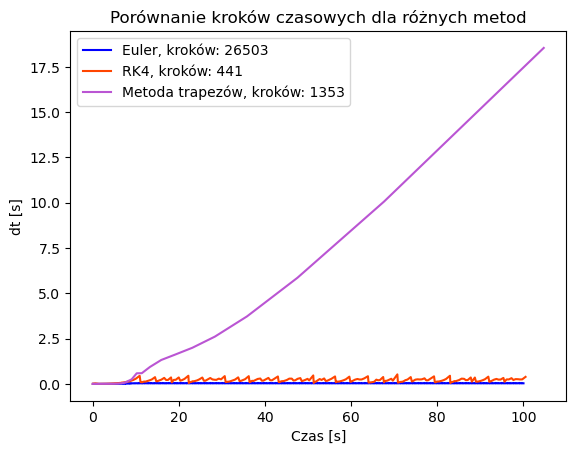

In [120]:
plt.figure("Kroki czasowe dla różnych metod z oporem")
plt.plot(time_euler1, dt_euler1, label=f"Euler, kroków: {steps_euler1}", color="blue")
plt.plot(time_rk41, dt_rk41, label=f"RK4, kroków: {steps_rk41}", color="orangered")
plt.plot(time_trapez1, dt_trapez1, label=f"Metoda trapezów, kroków: {steps_trapez1}", color="mediumorchid")

plt.legend(loc="upper left")
plt.xlabel("Czas [s]")
plt.ylabel("dt [s]")
plt.title("Porównanie kroków czasowych dla różnych metod")
#plt.ylim(0, 1)
plt.show()

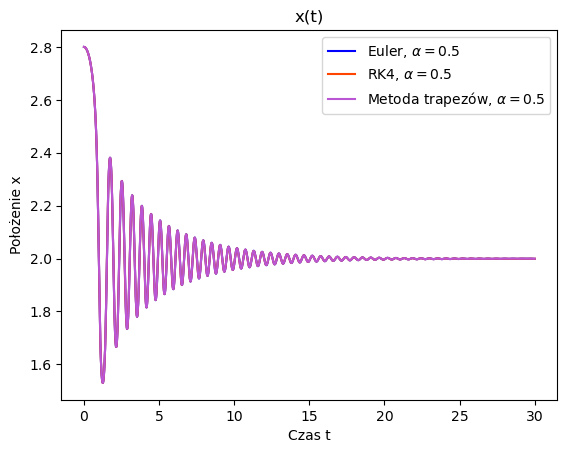

In [112]:
E_rk4 = energy(x_rk4, v_rk4)
E_euler = energy(x_euler, v_euler)
E_rk41 = energy(x_rk41, v_rk41)
E_euler1 = energy(x_euler1, v_euler1)
E_trapez = energy(x_trapez, v_trapez)
E_trapez1 = energy(x_trapez1, v_trapez1)

plt.figure(figsize=(14, 10))

# 1. x(t)
plt.subplot(2, 2, 1)
plt.plot(time_euler, x_euler, label="Euler, $\\alpha=0.5$", color="blue")
plt.plot(time_rk4, x_rk4, label="RK4, $\\alpha=0.5$", color="orangered")
plt.plot(time_trapez, x_trapez, label="Metoda trapezów, $\\alpha=0.5$", color="mediumorchid")
#plt.plot(time_trapez1, x_trapez1, label="Metoda trapezów, $\\alpha=5$", color="mediumorchid")
plt.title("x(t)")
plt.xlabel("Czas t")
plt.ylabel("Położenie x")
plt.legend(loc="upper right")

# 2. v(t)
plt.subplot(2, 2, 2)
plt.plot(time_trapez, v_trapez, label="Metoda trapezów, $\\alpha=0.5$", color="gold")
plt.plot(time_trapez1, v_trapez1, label="Metoda trapezów, $\\alpha=5$", color="mediumorchid")
plt.title("v(t)")
plt.xlabel("Czas t")
plt.ylabel("Prędkość v")
plt.legend(loc="upper right")

# 3. v(x)
plt.subplot(2, 2, 3)
plt.plot(x_trapez, v_trapez, label="Metoda trapezów, $\\alpha=0.5$", color="gold")
plt.plot(x_trapez1, v_trapez1, label="Metoda trapezów, $\\alpha=5$", color="mediumorchid")
plt.title("v(x) - portret fazowy")
plt.xlabel("Położenie x")
plt.ylabel("Prędkość v")
plt.legend(loc="upper right")

# 4. E(t)
plt.subplot(2, 2, 4)
plt.plot(time_trapez, E_trapez, label="Metoda trapezów, $\\alpha=0.5$", color="gold")
plt.plot(time_trapez1, E_trapez1, label="Metoda trapezów, $\\alpha=5$", color="mediumorchid")
plt.title("E(t)")
plt.xlabel("Czas t")
plt.ylabel("Energia E")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [122]:
# Różne opory a ilość kroków
alphas = [0.1, 0.5, 1, 3, 5, 10, 20, 50, 100]
steps_euler_list = []
steps_rk4_list = []
steps_trapez_list = []

for alpha in alphas:
    _, _, _, _, steps_euler = adaptive_solver(euler, d=1, name="Euler", alpha=alpha, t_max=100)
    _, _, _, _, steps_rk4 = adaptive_solver(rk4_step, d=3, name="RK4", alpha=alpha, t_max=100)
    _, _, _, _, steps_trapez = adaptive_solver(trapez, d=2, name="Trapez", alpha=alpha, t_max=100)

    steps_euler_list.append(steps_euler)
    steps_rk4_list.append(steps_rk4)
    steps_trapez_list.append(steps_trapez)


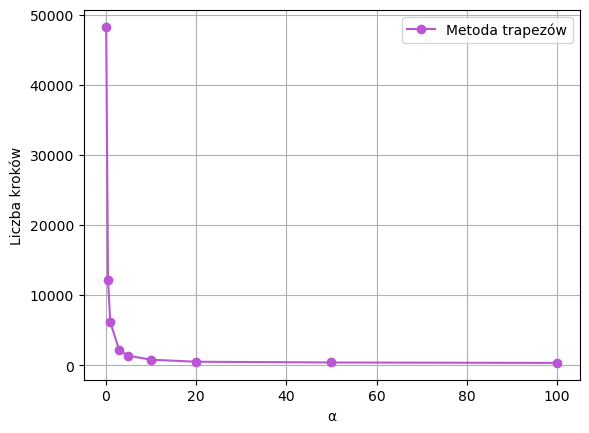

In [123]:
plt.figure()
plt.plot(alphas, steps_trapez_list, label="Metoda trapezów", marker='o', color='mediumorchid')
#plt.plot(alphas, steps_rk4_list, label="RK4", marker='o', color='orangered')
plt.xlabel("α")
plt.ylabel("Liczba kroków")
#plt.title("Zależność liczby kroków od tłumienia")
plt.legend()
plt.grid(True)
plt.show()